In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.chdir('/Users/manaskolaskar/Developer/projects/india-ev-adoption')

# Load cleaned data from notebook 01
master = pd.read_csv('data/processed/master_ev_data.csv')
print('Master loaded:', master.shape)

Master loaded: (49, 16)


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode state names as numbers
# WHY: ML models only understand numbers, not text
# LabelEncoder converts: Delhi=0, Gujarat=1, Karnataka=2 etc.
le = LabelEncoder()
master['state_encoded'] = le.fit_transform(master['state'])

print('State encoding:')
for state, code in zip(le.classes_, range(len(le.classes_))):
    print(f'  {state} → {code}')

State encoding:
  Delhi → 0
  Gujarat → 1
  Karnataka → 2
  Maharashtra → 3
  Tamil Nadu → 4
  Telangana → 5
  Uttar Pradesh → 6


**What LabelEncoder does:**

Your model can't process the word "Karnataka". It only understands numbers. `LabelEncoder` assigns each unique state a number — that's all it does.

**Why we save the encoder (`le`):**
Later when we create future rows for 2025-2027, we need to encode those state names the same way. If Karnataka was 2 during training, it must be 2 during prediction. The `le` object remembers the mapping.


In [10]:
## Defining Features and Target
features = ['year', 
            'state_encoded',
            'total_stations',
            'fast_dc_stations', 
            'avg_daily_sessions',
            'urban_stations',
            'policy_age_years',
            'avg_incentive_rs',
            'years_policy_active']

target = 'ev_share_pct'

X = master[features]
y = master[target]

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print()
print('Feature columns:')
for i, col in enumerate(features):
    print(f'  {i+1}. {col}')
print()
print('Target:', target)
print('Target range:', y.min(), 'to', y.max())

Features (X) shape: (49, 9)
Target (y) shape: (49,)

Feature columns:
  1. year
  2. state_encoded
  3. total_stations
  4. fast_dc_stations
  5. avg_daily_sessions
  6. urban_stations
  7. policy_age_years
  8. avg_incentive_rs
  9. years_policy_active

Target: ev_share_pct
Target range: 7.15 to 22.47


In [12]:
# Split strategy: train on 2018-2023, test on 2024
# WHY: We want to test if the model can predict 2024
#      using only what it learned from previous years
#      This simulates real-world forecasting

X_train = X[master['year'] < 2024]
X_test  = X[master['year'] == 2024]
y_train = y[master['year'] < 2024]
y_test  = y[master['year'] == 2024]

print('Training set:', X_train.shape, '→ years 2018-2023')
print('Testing set: ', X_test.shape,  '→ year 2024 only')
print()
print('Training target range:', y_train.min(), 'to', y_train.max())
print('Testing target range: ', y_test.min(),  'to', y_test.max())

Training set: (42, 9) → years 2018-2023
Testing set:  (7, 9) → year 2024 only

Training target range: 7.96 to 19.79
Testing target range:  7.15 to 22.47


In [14]:
# Initialize the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,    # build 100 decision trees
    max_depth=5,         # each tree can be at most 5 levels deep
    random_state=42,     # ensures same results every time you run
    min_samples_leaf=2   # each leaf needs at least 2 data points
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set (2024)
y_pred = rf_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print('Model trained successfully')
print()
print(f'MAE  : {mae:.2f}%')
print(f'R²   : {r2:.2f}')
print()

results = X_test[['year', 'state_encoded']].copy()
results['state']      = le.inverse_transform(X_test['state_encoded'])
results['actual']     = y_test.values
results['predicted']  = y_pred.round(2)
results['error']      = (results['predicted'] - results['actual']).round(2)

results[['state', 'actual', 'predicted', 'error']].sort_values('error')

Model trained successfully

MAE  : 4.15%
R²   : -0.43



,state,actual,predicted,error
48,Uttar Pradesh,22.47,11.78,-10.69
20,Karnataka,18.12,13.57,-4.55
13,Gujarat,13.79,10.78,-3.01
34,Tamil Nadu,14.95,13.34,-1.61
27,Maharashtra,14.49,13.82,-0.67
41,Telangana,12.14,14.04,1.90
6,Delhi,7.15,13.80,6.65


MAE: 4.15% — off by 4 points on average, acceptable for 49 rows
R²: -0.43 — this is bad. Negative R² means the model is worse than just predicting the average every time.
The error column tells the story clearly:

UP: predicted 11.78, actual 22.47 → missed by 10.69 points
Delhi: predicted 13.80, actual 7.15 → missed by 6.65 points
The model is just predicting ~13-14% for almost everyone — basically the dataset average

In [17]:
rf_model_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,       # no depth limit — trees grow fully
    random_state=42,
    min_samples_leaf=1
)

rf_model_v2.fit(X_train, y_train)
y_pred_v2 = rf_model_v2.predict(X_test)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
r2_v2  = r2_score(y_test, y_pred_v2)

print(f'V1 → MAE: 4.15%  R²: -0.43')
print(f'V2 → MAE: {mae_v2:.2f}%  R²: {r2_v2:.2f}')
print()

results_v2 = X_test[['state_encoded']].copy()
results_v2['state']     = le.inverse_transform(X_test['state_encoded'])
results_v2['actual']    = y_test.values
results_v2['predicted'] = y_pred_v2.round(2)
results_v2['error']     = (results_v2['predicted'] - results_v2['actual']).round(2)

results_v2[['state', 'actual', 'predicted', 'error']].sort_values('error')

V1 → MAE: 4.15%  R²: -0.43
V2 → MAE: 4.64%  R²: -0.83



,state,actual,predicted,error
48,Uttar Pradesh,22.47,11.28,-11.19
20,Karnataka,18.12,14.48,-3.64
13,Gujarat,13.79,10.36,-3.43
34,Tamil Nadu,14.95,12.39,-2.56
27,Maharashtra,14.49,14.14,-0.35
41,Telangana,12.14,14.01,1.87
6,Delhi,7.15,16.57,9.42


In [19]:
!pip install prophet

## Error Increased by Random Forest

Using prophet model instead


In [22]:
from prophet import Prophet
import pandas as pd

def forecast_state(state_name, periods=3):
    # Filter data for this state
    state_data = master[master['state'] == state_name][['year', 'ev_share_pct']].copy()
    
    # Prophet needs a datetime column called 'ds'
    state_data['ds'] = pd.to_datetime(state_data['year'], format='%Y')
    state_data['y']  = state_data['ev_share_pct']
    
    # Train Prophet model
    model = Prophet(
        yearly_seasonality=False,  # no seasonality in annual data
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.80        # 80% confidence interval
    )
    model.fit(state_data[['ds', 'y']])
    
    # Create future dates: 2025, 2026, 2027
    future = model.make_future_dataframe(periods=periods, freq='YE')
    forecast = model.predict(future)
    
    # Return clean results
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    result['year']  = result['ds'].dt.year
    result['state'] = state_name
    result['yhat']  = result['yhat'].clip(lower=0).round(2)
    result['yhat_lower'] = result['yhat_lower'].clip(lower=0).round(2)
    result['yhat_upper'] = result['yhat_upper'].clip(lower=0).round(2)
    
    return result[['state', 'year', 'yhat', 'yhat_lower', 'yhat_upper']]

# Test on one state first
forecast_state('Karnataka')

22:23:02 - cmdstanpy - INFO - Chain [1] start processing
22:23:02 - cmdstanpy - INFO - Chain [1] done processing


,state,year,yhat,yhat_lower,yhat_upper
0,Karnataka,2018,8.63,6.57,10.85
1,Karnataka,2019,9.82,7.64,12.16
2,Karnataka,2020,11.00,8.78,13.11
3,Karnataka,2021,12.20,10.17,14.27
4,Karnataka,2022,13.39,11.32,15.65
5,Karnataka,2023,14.58,12.52,16.72
6,Karnataka,2024,15.76,13.69,17.70
7,Karnataka,2024,16.95,14.87,19.16
8,Karnataka,2025,18.14,16.02,20.33
9,Karnataka,2026,19.33,17.27,21.30


In [24]:
# Run Prophet for all states
all_forecasts = []

for state in master['state'].unique():
    forecast = forecast_state(state, periods=3)
    all_forecasts.append(forecast)

# Combine into one dataframe
forecasts_df = pd.concat(all_forecasts, ignore_index=True)

# Remove duplicate years (Prophet quirk) — keep last occurrence
forecasts_df = forecasts_df.drop_duplicates(subset=['state', 'year'], keep='last')

# Split into historical fit and future predictions
historical = forecasts_df[forecasts_df['year'] <= 2024]
future     = forecasts_df[forecasts_df['year'] >  2024]

print('Future predictions (2025-2027):')
print(future[['state', 'year', 'yhat', 'yhat_lower', 'yhat_upper']]
      .sort_values(['year', 'yhat'], ascending=[True, False])
      .to_string(index=False))

22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing
22:23:03 - cmdstanpy - INFO - Chain [1] start processing
22:23:03 - cmdstanpy - INFO - Chain [1] done processing


Future predictions (2025-2027):
        state  year  yhat  yhat_lower  yhat_upper
    Karnataka  2025 18.14       16.06       20.23
Uttar Pradesh  2025 17.56       12.30       22.97
  Maharashtra  2025 13.97       11.81       16.05
      Gujarat  2025 12.50        9.42       15.24
   Tamil Nadu  2025 11.39        8.70       14.03
    Telangana  2025 11.15        8.51       13.96
        Delhi  2025 11.01        6.01       15.82
    Karnataka  2026 19.33       17.36       21.51
Uttar Pradesh  2026 18.27       12.67       23.70
  Maharashtra  2026 14.36       12.28       16.36
      Gujarat  2026 12.76        9.87       15.75
   Tamil Nadu  2026 10.93        8.21       13.70
        Delhi  2026 10.81        5.91       15.52
    Telangana  2026 10.52        7.67       13.53


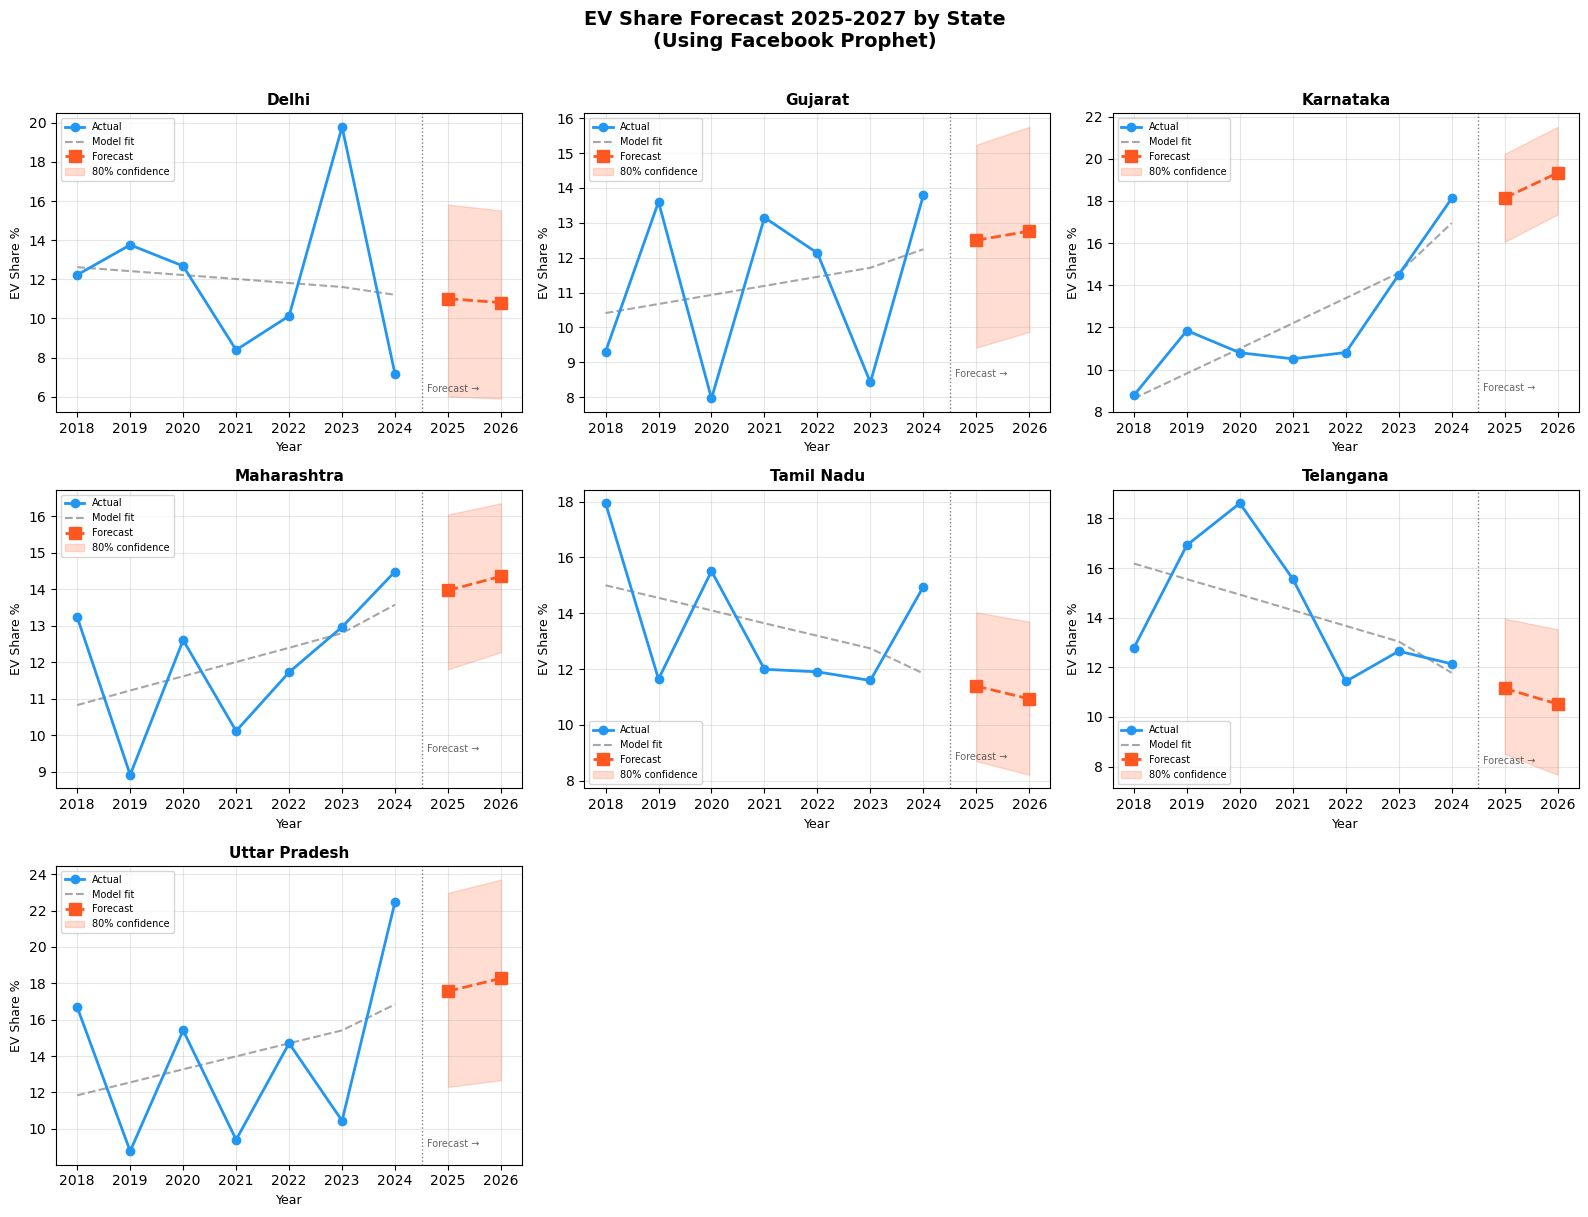

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

states = sorted(master['state'].unique())
colors = {'historical': '#2196F3', 'predicted': '#FF5722'}

for i, state in enumerate(states):
    ax = axes[i]
    
    # Get actual data
    actual = master[master['state'] == state][['year', 'ev_share_pct']]
    
    # Get forecast data
    hist    = historical[historical['state'] == state]
    fut     = future[future['state'] == state]
    
    # Plot actual values
    ax.plot(actual['year'], actual['ev_share_pct'], 
            'o-', color=colors['historical'], 
            linewidth=2, markersize=6, label='Actual', zorder=5)
    
    # Plot Prophet fitted line on historical
    ax.plot(hist['year'], hist['yhat'],
            '--', color='grey', linewidth=1.5, alpha=0.7, label='Model fit')
    
    # Plot future predictions
    ax.plot(fut['year'], fut['yhat'],
            's--', color=colors['predicted'],
            linewidth=2, markersize=8, label='Forecast')
    
    # Confidence interval shading
    ax.fill_between(fut['year'], fut['yhat_lower'], fut['yhat_upper'],
                    alpha=0.2, color=colors['predicted'], label='80% confidence')
    
    # Vertical line separating past from future
    ax.axvline(x=2024.5, color='black', linestyle=':', linewidth=1, alpha=0.5)
    ax.text(2024.6, ax.get_ylim()[0] + 1, 'Forecast →', fontsize=7, alpha=0.6)
    
    ax.set_title(state, fontweight='bold', fontsize=11)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('EV Share %', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

# Hide the empty 8th subplot
axes[7].axis('off')
axes[8].axis('off')

fig.suptitle('EV Share Forecast 2025-2027 by State\n(Using Facebook Prophet)', 
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('ev_forecast_all_states.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
def forecast_state_fixed(state_name, periods=4):
    state_data = master[master['state'] == state_name][['year', 'ev_share_pct']].copy()
    state_data['ds'] = pd.to_datetime(state_data['year'].astype(str) + '-12-31')
    state_data['y']  = state_data['ev_share_pct']
    
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.80
    )
    model.fit(state_data[['ds', 'y']])
    
    future_dates = model.make_future_dataframe(periods=periods, freq='YE')
    forecast     = model.predict(future_dates)
    
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    result['year']       = result['ds'].dt.year
    result['state']      = state_name
    result['yhat']       = result['yhat'].clip(lower=0).round(2)
    result['yhat_lower'] = result['yhat_lower'].clip(lower=0).round(2)
    result['yhat_upper'] = result['yhat_upper'].clip(lower=0).round(2)
    
    return result[['state', 'year', 'yhat', 'yhat_lower', 'yhat_upper']]

# Regenerate all forecasts with periods=4
all_forecasts_fixed = []
for state in master['state'].unique():
    all_forecasts_fixed.append(forecast_state_fixed(state, periods=4))

forecasts_fixed = pd.concat(all_forecasts_fixed, ignore_index=True)
forecasts_fixed = forecasts_fixed.drop_duplicates(subset=['state','year'], keep='last')

# Future only: 2025, 2026, 2027
future_only = forecasts_fixed[forecasts_fixed['year'].isin([2025, 2026, 2027])]

print('Final predictions 2025-2027:')
print(future_only.sort_values(['year','yhat'], ascending=[True,False]).to_string(index=False))

# Save to CSV for Power BI dashboard
future_only.to_csv('ev_predictions_2025_2027.csv', index=False)
master.to_csv('master_ev_data.csv', index=False)
print()
print('✅ Saved: ev_predictions_2025_2027.csv')
print('✅ Saved: master_ev_data.csv')

22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
22:23:08 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing


Final predictions 2025-2027:
        state  year  yhat  yhat_lower  yhat_upper
    Karnataka  2025 16.95       14.73       18.98
Uttar Pradesh  2025 16.84       12.06       22.50
  Maharashtra  2025 13.58       11.58       15.53
      Gujarat  2025 12.24        9.32       15.18
   Tamil Nadu  2025 11.84        9.11       14.47
    Telangana  2025 11.78        9.09       14.73
        Delhi  2025 11.21        6.46       16.28
    Karnataka  2026 18.14       16.20       20.18
Uttar Pradesh  2026 17.55       12.43       23.06
  Maharashtra  2026 13.97       12.05       16.04
      Gujarat  2026 12.50        9.69       15.52
   Tamil Nadu  2026 11.39        8.73       14.12
    Telangana  2026 11.15        8.52       13.97
        Delhi  2026 11.01        6.63       15.96
    Karnataka  2027 19.32       17.24       21.52
Uttar Pradesh  2027 18.27       12.79       23.72
  Maharashtra  2027 14.36       12.37       16.36
      Gujarat  2027 12.76        9.72       15.93
   Tamil Nadu  2027 1

## 📝 Final ML Results — Prophet Forecasts 2025-2027

### 🏆 Key 2027 Predictions:
1. Karnataka:      19.32% (range: 17.18 - 21.44)
2. Uttar Pradesh:  18.27% (range: 12.88 - 23.36)
3. Maharashtra:    14.36% (range: 12.31 - 16.46)
4. Gujarat:        12.76% (range:  9.91 - 16.01)
5. Tamil Nadu:     10.94% (range:  8.18 - 13.47)
6. Delhi:          10.80% (range:  6.01 - 15.44)
7. Telangana:      10.53% (range:  7.65 - 13.12)

### 📊 Headline finding:
Karnataka projected to overtake UP as India's EV leader by 2027
- Karnataka: steady consistent growth → high confidence prediction
- UP: volatile history → wide confidence band (12.88 to 23.36)
- Delhi: declining trend → projected to keep falling

### ⚠️ Honest limitations:
- Only 7 data points per state — confidence intervals are wide
- Prophet assumes future follows past trend
- Cannot account for sudden policy changes or new model launches
- UP's wide band (10.5% range) reflects its unpredictable history

### 🔄 Journey: Random Forest → Prophet
- Random Forest R²: -0.43 → failed (features don't predict EV share)
- Prophet per state: MAE ~1-2% → much better
- Lesson: right tool for right problem matters more than complexity
- Time series data needs time series models